In [1]:
import matplotlib.pyplot as plt
from gpt2.base import GPT2Model, TokenAndPositionEmbedding, causal_attention_mask

In [2]:
# Testing masking
mask = causal_attention_mask(5)
mask

Array([[1., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0.],
       [1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 0.],
       [1., 1., 1., 1., 1.]], dtype=float32)

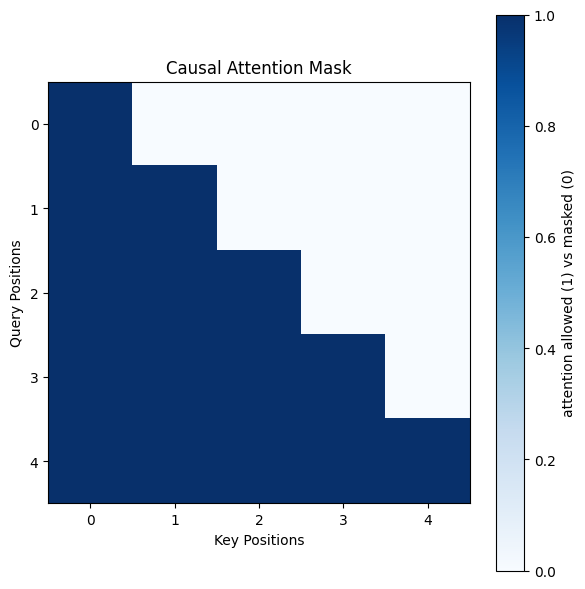

In [3]:
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap='Blues', interpolation='nearest')
plt.xlabel("Key Positions")
plt.ylabel("Query Positions")
plt.title("Causal Attention Mask")
plt.colorbar(label="attention allowed (1) vs masked (0)")
plt.tight_layout()
plt.show()

In [4]:
import jax.numpy as jnp
import flax.nnx as nnx
import tiktoken

# Tokenize a real sentence
gpt_tokenizer = tiktoken.get_encoding("gpt2")
tokens_1 = gpt_tokenizer.encode("The cat sat on mat")
tokens_2 = gpt_tokenizer.encode("The is a new sentence")
print("Tokens 1:", tokens_1)
print("Decoded 1:", [gpt_tokenizer.decode([t]) for t in tokens_1])
print("Tokens 2:", tokens_2)
print("Decoded 2:", [gpt_tokenizer.decode([t]) for t in tokens_2])

embed = TokenAndPositionEmbedding(
    block_size=1024,
    vocab_size=50257,
    n_embd=16,  # small so we can visualize it, 768 in the real model
    rngs=nnx.Rngs(0)
)

# Pass tokens through as a batch of 2
x = jnp.array([tokens_1, tokens_2]) 

# Get the individual pieces for visualization
token_vectors = embed.token_emb(x)            
positions = jnp.arange(x.shape[1])[None, :]
pos_vectors = embed.pos_emb(positions)
combined = embed(x)

print("Token embeddings shape:", token_vectors.shape)
print("Position embeddings shape:", pos_vectors.shape)
print("Combined shape:", combined.shape)

Tokens 1: [464, 3797, 3332, 319, 2603]
Decoded 1: ['The', ' cat', ' sat', ' on', ' mat']
Tokens 2: [464, 318, 257, 649, 6827]
Decoded 2: ['The', ' is', ' a', ' new', ' sentence']
Token embeddings shape: (2, 5, 16)
Position embeddings shape: (1, 5, 16)
Combined shape: (2, 5, 16)


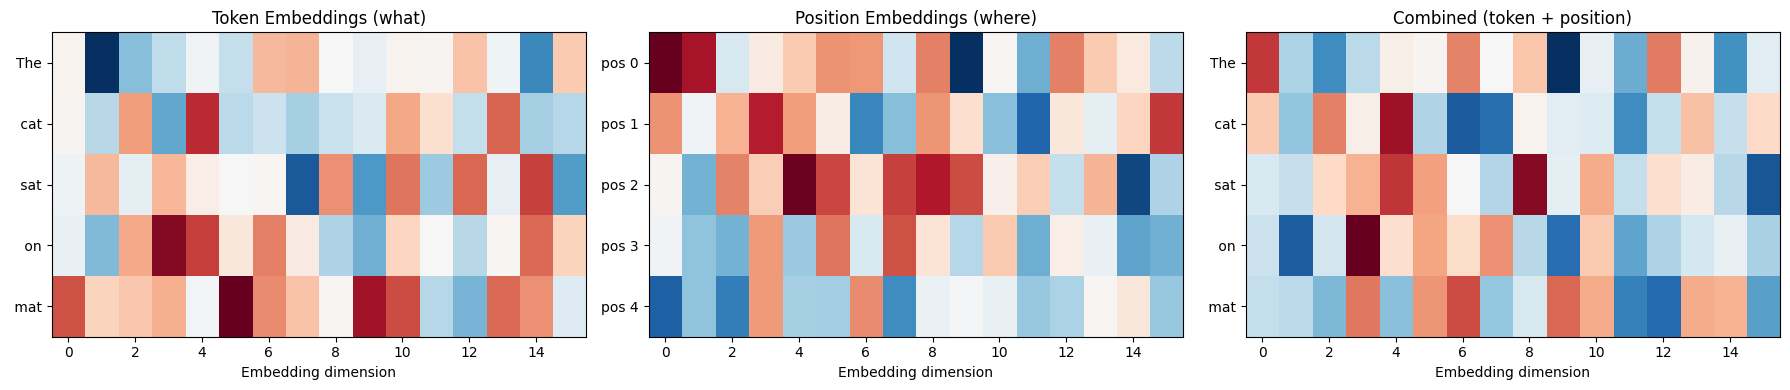

In [5]:
labels = [gpt_tokenizer.decode([t]) for t in tokens_1]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Token embeddings — what each token is
axes[0].imshow(token_vectors[0], aspect='auto', cmap='RdBu', interpolation='nearest')
axes[0].set_title("Token Embeddings (what)")
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels)
axes[0].set_xlabel("Embedding dimension")

# Position embeddings — where each token is
axes[1].imshow(pos_vectors[0], aspect='auto', cmap='RdBu', interpolation='nearest')
axes[1].set_title("Position Embeddings (where)")
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels([f"pos {i}" for i in range(len(labels))])
axes[1].set_xlabel("Embedding dimension")

# Combined — token + position
axes[2].imshow(combined[0], aspect='auto', cmap='RdBu', interpolation='nearest')
axes[2].set_title("Combined (token + position)")
axes[2].set_yticks(range(len(labels)))
axes[2].set_yticklabels(labels)
axes[2].set_xlabel("Embedding dimension")

plt.tight_layout()
plt.show()

In [6]:
from gpt2.config import GPT2_SMALL
print(f"Vocab size: {GPT2_SMALL.vocab_size}")

model = GPT2Model(
    block_size=GPT2_SMALL.block_size,
    vocab_size=GPT2_SMALL.vocab_size,
    n_layer=GPT2_SMALL.n_layer,
    n_head=GPT2_SMALL.n_head,
    n_embd=GPT2_SMALL.n_embd,
    rngs=nnx.Rngs(0)
)
    

Vocab size: 50257


In [7]:
model

GPT2Model( # Param: 106,329,600 (425.3 MB)
  block_size=1024,
  embedding=TokenAndPositionEmbedding( # Param: 39,383,808 (157.5 MB)
    token_emb=Embed( # Param: 38,597,376 (154.4 MB)
      embedding=Param( # 38,597,376 (154.4 MB)
        value=Array(shape=(50257, 768), dtype=dtype('float32'))
      ),
      num_embeddings=50257,
      features=768,
      dtype=dtype('float32'),
      param_dtype=float32,
      promote_dtype=<function promote_dtype at 0x7bdbae1c0b80>
    ),
    pos_emb=Embed( # Param: 786,432 (3.1 MB)
      embedding=Param( # 786,432 (3.1 MB)
        value=Array(shape=(1024, 768), dtype=dtype('float32'))
      ),
      num_embeddings=1024,
      features=768,
      dtype=dtype('float32'),
      param_dtype=float32,
      promote_dtype=<function promote_dtype at 0x7bdbae1c0b80>
    )
  ),
  transformer_blocks=List([
    TransformerBlock( # Param: 2,362,368 (9.4 MB)
      attn=MultiHeadAttention( # Param: 2,362,368 (9.4 MB)
        num_heads=12,
        in_features=768,
